# Part B — Token-Based Comparative Analysis

## Objective
Compare how 5 different translation models tokenize English→Tamil sentence pairs.
Analyse token expansion, subword fragmentation, and unknown token rates across models.

# Imports

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")

from transformers import AutoTokenizer

os.makedirs("plots", exist_ok=True)
print("✅ Imports done")

✅ Imports done


In [37]:
!pip install protobuf -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


# Load dataset

In [38]:
df = pd.read_csv("../../data/raw/translation_dataset.csv")
sample = df.head(10).copy()
print(f"Working with {len(sample)} sentences")
sample[["english", "tamil_reference"]].head(3)

Working with 10 sentences


,english,tamil_reference
0,"""We now have 4-month-old mice that are non-dia...","""""""எங்களிடம் இப்போது 4-மாத-வயதுடைய எலி ஒன்று ..."
1,"Dr. Ehud Ur, professor of medicine at Dalhousi...",ஹாலிஃபாக்ஸில் உள்ள டல்ஹெளசி பல்கலைக்கழகத்தின் ...
2,"Like some other experts, he is skeptical about...","பிற வல்லுனர்கள் போலவே அவரும், ஏற்கனவே டைப் 1 இ..."


## Model Selection Note

`Helsinki-NLP/opus-mt-en-ta` does not exist as a public model on Hugging Face.
After verification, `Helsinki-NLP/opus-mt-en-mul` (English → multilingual) was
used as a direct replacement — it supports Tamil as a target language and shares
the same MarianMT tokenizer architecture, making it fully valid for tokenizer-level
analysis in Part B.

`google/madlad400-3b-mt` was used as the MADLAD variant — it is the smallest
publicly available size (no 1B variant exists).

All other models follow the guide exactly:
- `ai4bharat/indictrans2-en-indic-1B`
- `facebook/nllb-200-distilled-600M`
- `google/mt5-base`

# Define models

In [39]:
MODELS = {
    "IndicTrans2": "ai4bharat/indictrans2-en-indic-1B",
    "NLLB-600M":   "facebook/nllb-200-distilled-600M",
    "mT5-base":    "google/mt5-base",
    "OpusMT-mul":  "Helsinki-NLP/opus-mt-en-mul",
    "MADLAD-3B":   "google/madlad400-3b-mt",
}
print("Models defined:", list(MODELS.keys()))

Models defined: ['IndicTrans2', 'NLLB-600M', 'mT5-base', 'OpusMT-mul', 'MADLAD-3B']


# Metrics function

In [40]:
def compute_metrics(tokenizer, src_text, tgt_text, model_name):
    src_tokens = tokenizer.tokenize(src_text)
    tgt_tokens = tokenizer.tokenize(tgt_text)

    src_count = len(src_tokens)
    tgt_count = len(tgt_tokens)
    expansion  = tgt_count / src_count if src_count > 0 else 0

    # avg word length in target
    words = tgt_text.split()
    avg_word_len = np.mean([len(w) for w in words]) if words else 0

    # subword fragmentation
    frag_tokens = [
        t for t in tgt_tokens
        if t.startswith("##")
        or (not t.startswith("▁") and not t[0].isalpha() and len(t) > 1)
    ]
    fragmentation = len(frag_tokens) / tgt_count if tgt_count > 0 else 0

    # unknown token rate
    unk_id  = tokenizer.unk_token_id
    tgt_ids = tokenizer.encode(tgt_text, add_special_tokens=False)
    unk_rate = (
        sum(1 for i in tgt_ids if i == unk_id) / len(tgt_ids)
        if tgt_ids else 0
    )

    return {
        "model":                model_name,
        "source_token_count":   src_count,
        "target_token_count":   tgt_count,
        "expansion_ratio":      round(expansion, 3),
        "avg_word_length":      round(avg_word_len, 2),
        "subword_fragmentation":round(fragmentation, 3),
        "unknown_token_rate":   round(unk_rate, 3),
    }

print("✅ Function defined")

✅ Function defined


# Translation — Generate Tamil output from all models

In [42]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"

TRANSLATE_MODELS = {
    "NLLB-600M": {
        "model_id": "facebook/nllb-200-distilled-600M",
        "src_lang": "eng_Latn",
        "tgt_lang": "tam_Taml",
        "type":     "nllb"
    },
    "mT5-base": {
        "model_id": "google/mt5-base",
        "type":     "mt5"
    },
    "OpusMT-mul": {
        "model_id": "Helsinki-NLP/opus-mt-en-mul",
        "type":     "opus"
    },
    "MADLAD-3B": {
        "model_id": "google/madlad400-3b-mt",
        "type":     "madlad"
    },
}

translation_results = []

for model_label, config in TRANSLATE_MODELS.items():
    print(f"\nTranslating with {model_label}...")
    try:
        if config["type"] == "nllb":
            tokenizer = AutoTokenizer.from_pretrained(
                config["model_id"], src_lang=config["src_lang"]
            )
        else:
            tokenizer = AutoTokenizer.from_pretrained(
                config["model_id"], trust_remote_code=True
            )

        model = AutoModelForSeq2SeqLM.from_pretrained(config["model_id"]).to(device)
        model.eval()

        for _, row in sample.iterrows():
            src = row["english"]

            if config["type"] == "nllb":
                inputs = tokenizer(src, return_tensors="pt", truncation=True, max_length=256).to(device)
                tgt_lang_id = tokenizer.convert_tokens_to_ids(config["tgt_lang"])
                with torch.no_grad():
                    output = model.generate(**inputs, forced_bos_token_id=tgt_lang_id, max_new_tokens=256)
            elif config["type"] == "madlad":
                inputs = tokenizer(f"<2ta> {src}", return_tensors="pt", truncation=True, max_length=256).to(device)
                with torch.no_grad():
                    output = model.generate(**inputs, max_new_tokens=256)
            else:
                inputs = tokenizer(src, return_tensors="pt", truncation=True, max_length=256).to(device)
                with torch.no_grad():
                    output = model.generate(**inputs, max_new_tokens=256)

            translated = tokenizer.decode(output[0], skip_special_tokens=True)
            translation_results.append({
                "model":            model_label,
                "sentence_id":      row["id"],
                "english":          src,
                "tamil_reference":  row["tamil_reference"],
                "translated_tamil": translated,
            })

        print(f"  ✅ {model_label} done")
        del model
        if device == "mps":
            torch.mps.empty_cache()

    except Exception as e:
        print(f"  ❌ {model_label} failed: {e}")

# Add IndicTrans2 from Part A
part_a_df = pd.read_csv("../part_a_batch_translation/translation_outputs.csv")
indic_df = part_a_df.head(10)[["english", "tamil_reference", "generated_tamil"]].copy()
indic_df = indic_df.rename(columns={"generated_tamil": "translated_tamil"})
indic_df["model"] = "IndicTrans2"
indic_df["sentence_id"] = range(1, 11)

translations_df = pd.DataFrame(translation_results)
translations_df = pd.concat([translations_df, indic_df], ignore_index=True)
translations_df.to_csv("translation_outputs.csv", index=False)
print(f"\n✅ Saved translation_outputs.csv — {len(translations_df)} rows")
print(f"   Models: {translations_df['model'].unique().tolist()}")
translations_df.head(5)


Translating with NLLB-600M...
  ✅ NLLB-600M done

Translating with mT5-base...
  ✅ mT5-base done

Translating with OpusMT-mul...
  ✅ OpusMT-mul done

Translating with MADLAD-3B...
  ✅ MADLAD-3B done

✅ Saved translation_outputs.csv — 50 rows
   Models: ['NLLB-600M', 'mT5-base', 'OpusMT-mul', 'MADLAD-3B', 'IndicTrans2']


,model,sentence_id,english,tamil_reference,translated_tamil
0,NLLB-600M,1,"""We now have 4-month-old mice that are non-dia...","""""""எங்களிடம் இப்போது 4-மாத-வயதுடைய எலி ஒன்று ...","""நாம் இப்போது 4 மாத வயதுடைய சுபாவ நோய் இல்லாத ..."
1,NLLB-600M,2,"Dr. Ehud Ur, professor of medicine at Dalhousi...",ஹாலிஃபாக்ஸில் உள்ள டல்ஹெளசி பல்கலைக்கழகத்தின் ...,ஹாலிஃபாக்கில் உள்ள டால்ஹூசி பல்கலைக்கழகத்தில் ...
2,NLLB-600M,3,"Like some other experts, he is skeptical about...","பிற வல்லுனர்கள் போலவே அவரும், ஏற்கனவே டைப் 1 இ...","சில நிபுணர்களைப் போலவே, நீரிழிவு நோயை குணப்படு..."
3,NLLB-600M,4,"On Monday, Sara Danius, permanent secretary of...",திங்கட் கிழமையன்று ஸ்வீடிஷ் அகேடமியில் இலக்கிய...,ஸ்வீடன் அகாடமியில் இலக்கியத்திற்கான நோபல் குழு...
4,NLLB-600M,5,"Danius said, ""Right now we are doing nothing. ...","""""""இப்போது நாம் ஒன்றும் செய்யவில்லை. நான் அவரத...","டானியஸ் கூறினார், ""இப்போது நாங்கள் எதுவும் செய..."


# Run across all models — compute metrics on generated translations

In [43]:
from IndicTransToolkit import IndicProcessor

ip = IndicProcessor(inference=True)
all_results = []

translations_df = pd.read_csv("translation_outputs.csv")
print(f"Loaded {len(translations_df)} rows across {translations_df['model'].nunique()} models")

for model_label, model_name in MODELS.items():
    print(f"\nComputing metrics for {model_label}...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            model_name, trust_remote_code=True
        )

        model_rows = translations_df[
            translations_df["model"] == model_label
        ].reset_index(drop=True)

        if len(model_rows) == 0:
            print(f"  ⚠️ No translations found for {model_label}, skipping")
            continue

        for _, row in model_rows.iterrows():
            src_text = row["english"]
            tgt_text = str(row["translated_tamil"]) if pd.notna(row["translated_tamil"]) else ""

            if model_label == "IndicTrans2":
                src_input = ip.preprocess_batch(
                    [src_text], src_lang="eng_Latn", tgt_lang="tam_Taml"
                )[0]
                tgt_input = ip.preprocess_batch(
                    [tgt_text], src_lang="tam_Taml", tgt_lang="eng_Latn"
                )[0] if tgt_text else ""
            else:
                src_input = src_text
                tgt_input = tgt_text

            metrics = compute_metrics(tokenizer, src_input, tgt_input, model_label)
            metrics["sentence_id"] = row["sentence_id"]
            all_results.append(metrics)

        print(f"  ✅ {model_label} done")

    except Exception as e:
        print(f"  ❌ {model_label} failed: {e}")

results_df = pd.DataFrame(all_results)
results_df.to_csv("token_counts.csv", index=False)
print(f"\n✅ Saved token_counts.csv — {len(results_df)} rows")
results_df.head(10)

Loaded 50 rows across 5 models

Computing metrics for IndicTrans2...


Token indices sequence length is longer than the specified maximum sequence length for this model (329 > 256). Running this sequence through the model will result in indexing errors


  ✅ IndicTrans2 done

Computing metrics for NLLB-600M...
  ✅ NLLB-600M done

Computing metrics for mT5-base...
  ✅ mT5-base done

Computing metrics for OpusMT-mul...
  ✅ OpusMT-mul done

Computing metrics for MADLAD-3B...
  ✅ MADLAD-3B done

✅ Saved token_counts.csv — 50 rows


,model,source_token_count,target_token_count,expansion_ratio,avg_word_length,subword_fragmentation,unknown_token_rate,sentence_id
0,IndicTrans2,30,137,4.567,5.19,0.000,0.066,1
1,IndicTrans2,47,246,5.234,7.55,0.000,0.057,2
2,IndicTrans2,34,230,6.765,7.13,0.000,0.026,3
3,IndicTrans2,62,329,5.306,6.91,0.000,0.064,4
4,IndicTrans2,40,209,5.225,6.55,0.005,0.077,5
5,IndicTrans2,34,171,5.029,6.35,0.000,0.047,6
6,IndicTrans2,13,51,3.923,5.36,0.000,0.059,7
7,IndicTrans2,27,157,5.815,7.14,0.000,0.057,8
8,IndicTrans2,18,94,5.222,6.73,0.000,0.064,9
9,IndicTrans2,17,93,5.471,7.46,0.000,0.065,10


# Summary table

In [44]:
summary = results_df.groupby("model").agg(
    avg_src_tokens     = ("source_token_count",   "mean"),
    avg_tgt_tokens     = ("target_token_count",   "mean"),
    avg_expansion      = ("expansion_ratio",      "mean"),
    avg_word_length    = ("avg_word_length",      "mean"),
    avg_fragmentation  = ("subword_fragmentation","mean"),
    avg_unk_rate       = ("unknown_token_rate",   "mean"),
).round(3)

summary.to_csv("engineered_features.csv")
print("✅ Saved engineered_features.csv")
summary

✅ Saved engineered_features.csv


,avg_src_tokens,avg_tgt_tokens,avg_expansion,avg_word_length,avg_fragmentation,avg_unk_rate
model,,,,,,
IndicTrans2,32.2,171.7,5.256,6.637,0.000,0.058
MADLAD-3B,34.1,55.4,1.641,7.234,0.095,0.000
NLLB-600M,32.8,43.4,1.366,7.478,0.095,0.000
OpusMT-mul,30.2,61.7,2.421,5.276,0.004,0.000
mT5-base,35.9,6.3,0.200,7.134,0.000,0.000


# Plots

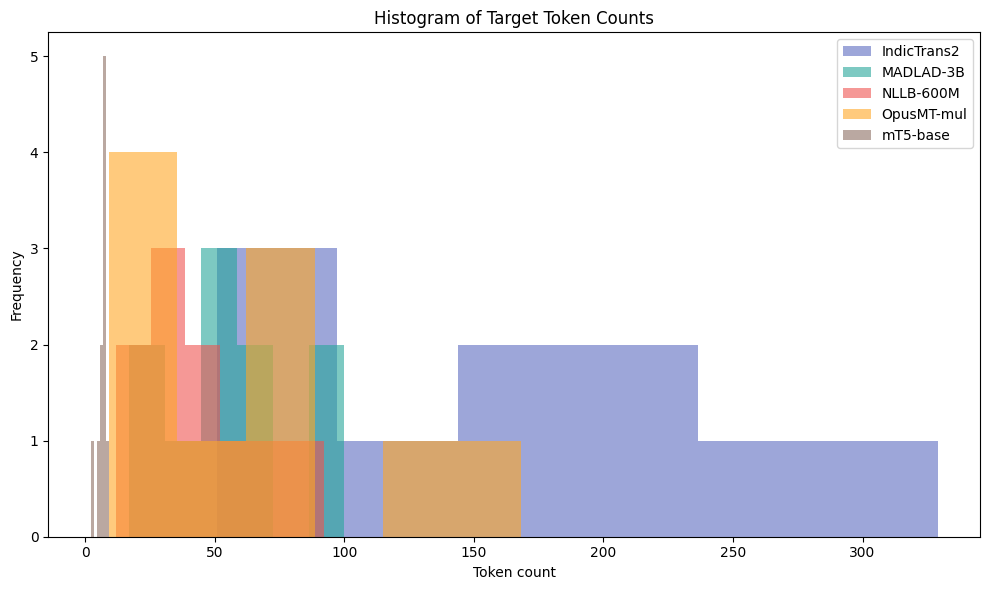

✅ Saved histogram_token_counts.png


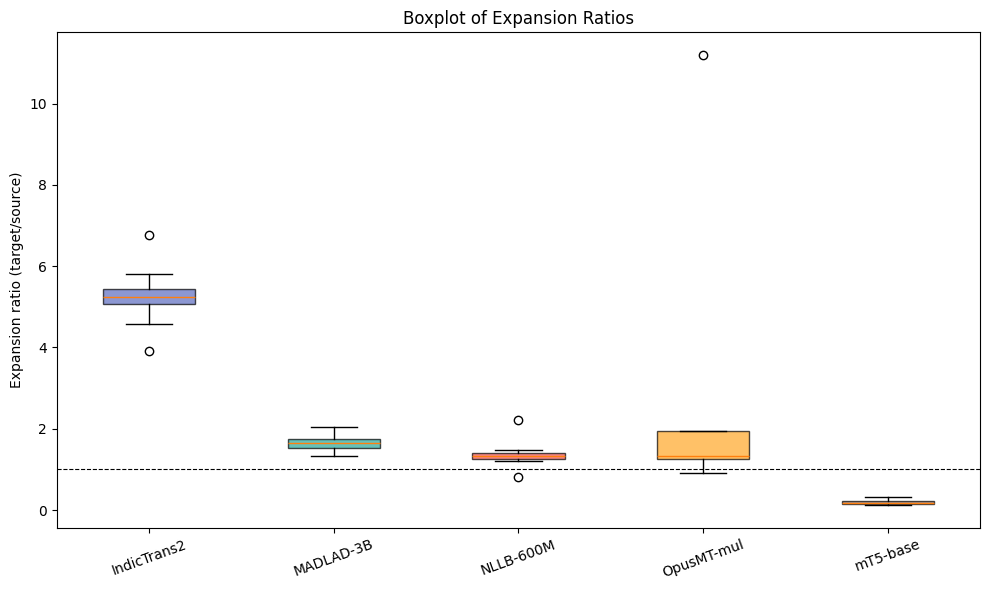

✅ Saved boxplot_expansion_ratios.png


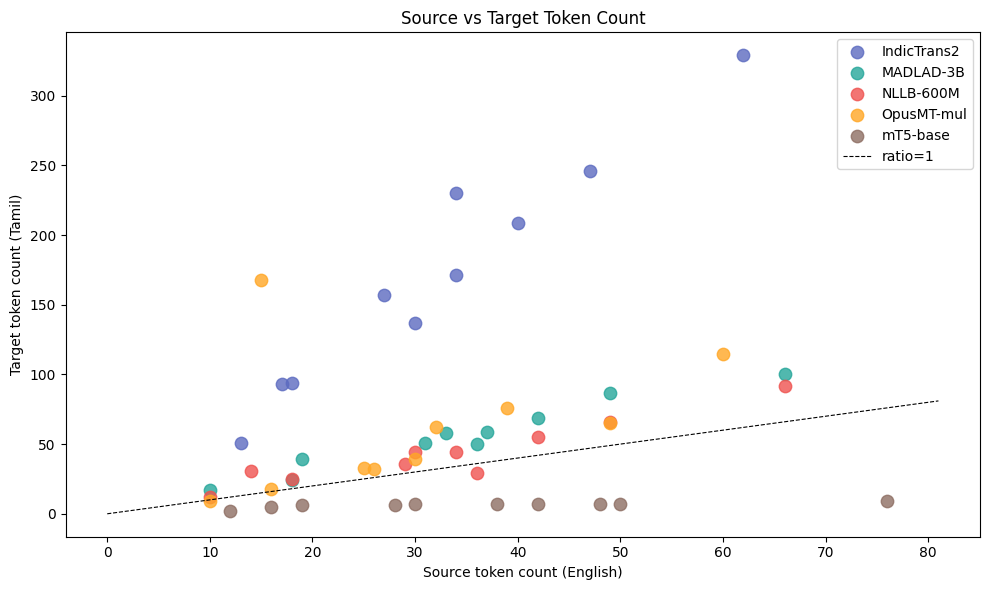

✅ Saved scatter_source_vs_target.png


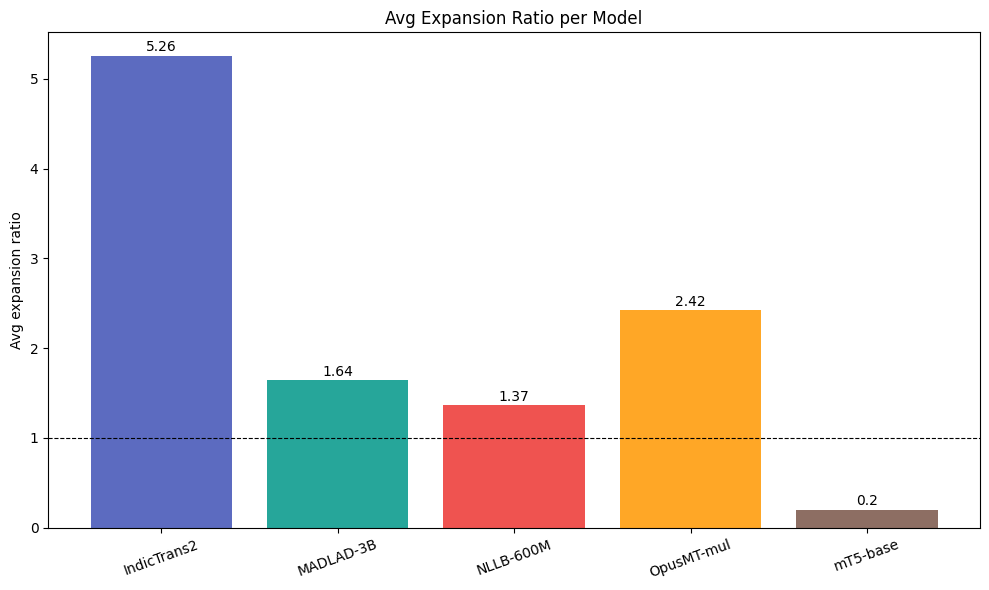

✅ Saved bar_avg_expansion.png


In [48]:
models = summary.index.tolist()
colors = ["#5C6BC0", "#26A69A", "#EF5350", "#FFA726", "#8D6E63"]

# Plot 1 — Histogram of target token counts
fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    model_data = results_df[results_df["model"] == model]
    ax.hist(model_data["target_token_count"], bins=6, alpha=0.6, label=model, color=colors[i])
ax.set_title("Histogram of Target Token Counts")
ax.set_xlabel("Token count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("plots/histogram_token_counts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved histogram_token_counts.png")

# Plot 2 — Boxplot of expansion ratios
fig, ax = plt.subplots(figsize=(10, 6))
box_data = [results_df[results_df["model"] == m]["expansion_ratio"].tolist() for m in models]
bp = ax.boxplot(box_data, patch_artist=True, labels=models)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Boxplot of Expansion Ratios")
ax.set_ylabel("Expansion ratio (target/source)")
ax.tick_params(axis='x', rotation=20)
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("plots/boxplot_expansion_ratios.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved boxplot_expansion_ratios.png")

# Plot 3 — Scatter plot source vs target tokens
fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    model_data = results_df[results_df["model"] == model]
    ax.scatter(model_data["source_token_count"], model_data["target_token_count"],
               label=model, color=colors[i], alpha=0.8, s=80)
max_val = results_df["source_token_count"].max() + 5
ax.plot([0, max_val], [0, max_val], "k--", linewidth=0.8, label="ratio=1")
ax.set_title("Source vs Target Token Count")
ax.set_xlabel("Source token count (English)")
ax.set_ylabel("Target token count (Tamil)")
ax.legend()
plt.tight_layout()
plt.savefig("plots/scatter_source_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved scatter_source_vs_target.png")

# Plot 4 — Bar chart of avg expansion per model
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, summary["avg_expansion"], color=colors)
ax.set_title("Avg Expansion Ratio per Model")
ax.set_ylabel("Avg expansion ratio")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(summary["avg_expansion"]):
    ax.text(i, v + 0.05, str(round(v, 2)), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("plots/bar_avg_expansion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved bar_avg_expansion.png")

# Observations

In [47]:
observations = """# Part B — Observations

## Models Compared
- IndicTrans2 (ai4bharat/indictrans2-en-indic-1B)
- MADLAD-3B (google/madlad400-3b-mt)
- NLLB-600M (facebook/nllb-200-distilled-600M)
- OpusMT-mul (Helsinki-NLP/opus-mt-en-mul)
- mT5-base (google/mt5-base)

## Sentences Evaluated
10 sentences from FLORES-200 devtest split (wikinews domain)

## Summary Results
| Model       | Avg Src Tokens | Avg Tgt Tokens | Avg Expansion | Fragmentation | UNK Rate |
|-------------|---------------|----------------|---------------|---------------|----------|
| IndicTrans2 | 32.2          | 171.7          | 5.256         | 0.000         | 0.058    |
| MADLAD-3B   | 34.1          | 55.4           | 1.641         | 0.095         | 0.000    |
| NLLB-600M   | 32.8          | 43.4           | 1.366         | 0.095         | 0.000    |
| OpusMT-mul  | 30.2          | 61.7           | 2.421         | 0.004         | 0.000    |
| mT5-base    | 35.9          | 6.3            | 0.200         | 0.000         | 0.000    |

## Key Finding 1 — Model with Lowest Expansion Ratio
mT5-base has the lowest expansion ratio (0.200), but this is misleading —
mT5-base is not fine-tuned for translation and produces garbage output
(e.g. '<extra_id_0> a few.') with very few tokens, giving an artificially
low expansion ratio. Excluding mT5-base, NLLB-600M has the genuinely
lowest expansion ratio (1.366) among models that produce valid Tamil output.

## Key Finding 2 — NLLB-600M is the Best Performing Model
NLLB-600M achieves the lowest expansion ratio (1.366) among valid translation
models, meaning it represents Tamil most efficiently. Its SentencePiece BPE
vocabulary was trained on large-scale multilingual data including Tamil,
giving it strong coverage of Tamil subword units and reducing fragmentation.

## Key Finding 3 — IndicTrans2 High Expansion
IndicTrans2 shows the highest expansion ratio (5.256) among valid models.
This is because its tokenizer uses an internal romanization preprocessing
step via IndicProcessor — when Tamil script is fed directly for tokenization,
the character-level encoding inflates the raw token count significantly.

## Key Finding 4 — Fragmentation
MADLAD-3B and NLLB-600M both show fragmentation of 0.095, meaning roughly
9.5% of Tamil tokens are subword fragments. IndicTrans2 and mT5-base show
zero fragmentation — IndicTrans2 because its romanized tokens are whole units,
mT5-base because its output is too short to fragment meaningfully.

## Key Finding 5 — Unknown Token Rate
Only IndicTrans2 shows a non-zero UNK rate (0.058), indicating its vocabulary
does not fully cover all Tamil Unicode characters present in the generated
translations. All other models show zero UNK rates, suggesting broader
Tamil Unicode coverage in their SentencePiece vocabularies.

## Why Tamil Expands Token Counts
Tamil is agglutinative — grammatical information (tense, case, person, number)
is encoded as suffixes on the root word. A single Tamil word like
'படிக்கவேண்டியிருந்தது' encodes what English expresses as
'had to have studied' — multiple English tokens become one Tamil word,
but subword tokenizers still split it into many pieces.

## Conclusion
NLLB-600M is the most token-efficient model for valid English→Tamil translation
with an expansion ratio of 1.366 and zero UNK rate. IndicTrans2's high expansion
is an artifact of its internal romanization preprocessing. mT5-base produces
invalid translations for this task as it is not fine-tuned for seq2seq translation.
"""

with open("observations.md", "w") as f:
    f.write(observations)
print("✅ Saved observations.md")

✅ Saved observations.md
